<a href="https://colab.research.google.com/github/ssurapaneni34/702project/blob/main/MIMIC_PREPROCESSING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MIMIC-IV → PyHealth Patient Cards (v4)
**ICU-only · data-driven top-K · interpretable names · clinical_summary for debate agents**

### What changed from v3
| | v3 | v4 |
|---|---|---|
| Feature names | `ce_220045_val` (opaque item IDs) | `heart_rate_val` (human-readable, from d_items) |
| Duplicate names | N/A | deduplicated with `_2`, `_3` suffixes |
| Debate agent support | None | `clinical_summary` block added to every card |

### Full card format
```python
{
  # ── PyHealth fields (unchanged) ──────────────────────────────────────────
  'patient_id':  '10000032',
  'visit_id':    '20000294',
  'stay_id':     '30000001',
  'conditions':  [],
  'procedures':  ['0BH17EZ', ...],   # ICD-10-PCS codes
  'drugs':       ['propofol', ...],  # unique drug names
  # ── LSTM input ───────────────────────────────────────────────────────────
  'time_series': [[hr_val, hr_mask, map_val, map_mask, ...], ...],  # (12, 2*K)
  'feature_names': ['heart_rate_val', 'heart_rate_mask', ...],
  # ── Label ────────────────────────────────────────────────────────────────
  'label':    4,
  'icd_code': 'A419',
  # ── Debate agent input ───────────────────────────────────────────────────
  'clinical_summary': {
    'vitals': {
      'heart_rate':  {'mean': 92.3, 'min': 68.0, 'max': 118.0, 'last': 88.0, 'trend': 'stable'},
      'map':         {'mean': 58.1, 'min': 44.0, 'max': 72.0,  'last': 62.0, 'trend': 'improving'},
      ...  # only features with mask > 0 at least once
    },
    'labs': {
      'creatinine': {'mean': 2.4, 'min': 1.9, 'max': 3.1, 'last': 2.8, 'trend': 'worsening'},
      ...
    },
    'interventions': {
      'active_drugs':      ['norepinephrine', 'propofol', 'normal saline'],  # seen in any hour
      'active_procedures': ['invasive ventilation', 'arterial line'],
      'urine_output_total_ml': 320.0,
    },
    'observation_hours': 12,          # always 12
    'pct_hours_monitored': 0.83,       # fraction of hours with >= 1 vital observed
  }
}
```

The `clinical_summary` is what debate agents quote in their arguments:
*"Patient shows worsening creatinine (1.9→2.8) with low MAP (mean 58 mmHg) on norepinephrine — consistent with septic shock (A419) rather than simple UTI (N390)."*

## 0 · Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import importlib
for pkg in ['torch', 'numpy', 'pandas', 'tqdm', 'matplotlib']:
    print(f'  {pkg:<12} {importlib.import_module(pkg).__version__}')
print('All pre-installed packages intact.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  torch        2.10.0+cpu
  numpy        2.0.2
  pandas       2.2.2
  tqdm         4.67.3
  matplotlib   3.10.0
All pre-installed packages intact.


## 1 · Configuration

In [ ]:
import os

MIMIC_DIR = '/content/drive/MyDrive/702 project/mimic_data'          # ← root of MIMIC-IV
OUT_PATH  = '/content/drive/MyDrive/702 project/patient_cards_v2.json'

'''
filter to top k of each item by frequency
'''
TOP_K_DX  = 50    # ICD-10 label classes
K_CHART   = 100   # top chartevents item IDs
K_LAB     = 50    # top labevents item IDs
K_INPUT   = 50    # top inputevents item IDs
K_PROC    = 50    # top procedureevents item IDs

for sub in ['hosp', 'icu']:
    p = os.path.join(MIMIC_DIR, sub)
    if not os.path.isdir(p): raise FileNotFoundError(p)
    print(f'  ✓  {p}')
print('Paths OK')

  ✓  /content/drive/MyDrive/702 project/mimic_data/hosp
  ✓  /content/drive/MyDrive/702 project/mimic_data/icu
Paths OK


## 2 · Helpers

In [ ]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

def csv_path(rel):
    full = os.path.join(MIMIC_DIR, rel)
    return full + '.gz' if os.path.exists(full + '.gz') else full

def load_csv(rel, **kw):
    p = csv_path(rel)
    print(f'  Loading {p} …')
    return pd.read_csv(p, **kw)

def stream_filter(rel, filter_col, filter_set, item_col, item_set, usecols, cs=500_000):
    p = csv_path(rel)
    print(f'  Streaming {os.path.basename(p)} …')
    chunks = []
    for chunk in tqdm(pd.read_csv(p, usecols=usecols, chunksize=cs, low_memory=False),
                      desc=os.path.basename(rel)):
        mask = chunk[filter_col].isin(filter_set)
        if item_col and item_set:
            mask &= chunk[item_col].isin(item_set)
        chunk = chunk[mask]
        if not chunk.empty:
            chunks.append(chunk)
    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame(columns=usecols)

def stream_topk_counts(rel, filter_col, filter_set, item_col, usecols, cs=500_000):
    p = csv_path(rel)
    print(f'  Counting frequencies in {os.path.basename(p)} …')
    counts = {}
    for chunk in tqdm(pd.read_csv(p, usecols=usecols, chunksize=cs, low_memory=False),
                      desc='freq'):
        chunk = chunk[chunk[filter_col].isin(filter_set)]
        for iid, cnt in chunk[item_col].value_counts().items():
            counts[iid] = counts.get(iid, 0) + cnt
    return pd.Series(counts).sort_values(ascending=False)

print('Helpers defined ✓')

Helpers defined ✓


## 3 · Labels

In [ ]:
import matplotlib.pyplot as plt

dx = load_csv('hosp/diagnoses_icd.csv',
              usecols=['subject_id','hadm_id','seq_num','icd_code','icd_version'])
dx = dx[(dx['seq_num']==1) & (dx['icd_version']==10)].copy()
dx['icd_code'] = dx['icd_code'].str.strip()

freq      = dx['icd_code'].value_counts()
top_codes = freq.head(TOP_K_DX).index.tolist()
label_map = {code: idx for idx, code in enumerate(top_codes)}
dx_top    = dx[dx['icd_code'].isin(top_codes)][['hadm_id','icd_code']]
print(f'Label map: {len(label_map)} classes')

  Loading /content/drive/MyDrive/702 project/mimic_data/hosp/diagnoses_icd.csv.gz …
Label map: 50 classes


In [ ]:
print(label_map)

{'A419': 0, 'F329': 1, 'Z5111': 2, 'F10129': 3, 'I130': 4, 'I214': 5, 'R079': 6, 'N179': 7, 'I110': 8, 'N390': 9, 'R0789': 10, 'J189': 11, 'U071': 12, 'R55': 13, 'I25110': 14, 'I2510': 15, 'I350': 16, 'J441': 17, 'I2699': 18, 'I671': 19, 'I480': 20, 'F29': 21, 'A4151': 22, 'K7031': 23, 'A4189': 24, 'T814XXA': 25, 'R45851': 26, 'J690': 27, 'F10239': 28, 'S065X0A': 29, 'K921': 30, 'O480': 31, 'L03116': 32, 'E1165': 33, 'I4891': 34, 'K3580': 35, 'I5033': 36, 'F332': 37, 'C7931': 38, 'I5023': 39, 'R109': 40, 'O34211': 41, 'L03115': 42, 'T82868A': 43, 'M1711': 44, 'F10229': 45, 'F319': 46, 'I472': 47, 'R42': 48, 'I132': 49}


## 4 · ICU Cohort

In [ ]:
icu = load_csv('icu/icustays.csv',
               usecols=['subject_id','hadm_id','stay_id','intime','outtime'])
print(icu.head())
icu['intime']    = pd.to_datetime(icu['intime'])
icu['outtime']   = pd.to_datetime(icu['outtime'])
icu['los_hours'] = (icu['outtime'] - icu['intime']).dt.total_seconds() / 3600
icu = icu.merge(dx_top, on='hadm_id', how='inner')
icu = icu[icu['los_hours'] >= 12].copy()
icu['window_end']   = icu['outtime']
icu['window_start'] = icu['window_end'] - pd.Timedelta(hours=12)

stay_ids = set(icu['stay_id'])
hadm_ids = set(icu['hadm_id'])
print("filtered to patients with icu stay > 12 hours")
print(f'Cohort: {len(icu):,} stays | {icu["subject_id"].nunique():,} patients')

  Loading /content/drive/MyDrive/702 project/mimic_data/icu/icustays.csv.gz …
   subject_id   hadm_id   stay_id               intime              outtime
0    10000032  29079034  39553978  2180-07-23 14:00:00  2180-07-23 23:50:47
1    10000690  25860671  37081114  2150-11-02 19:37:00  2150-11-06 17:03:17
2    10000980  26913865  39765666  2189-06-27 08:42:00  2189-06-27 20:38:27
3    10001217  24597018  37067082  2157-11-20 19:18:02  2157-11-21 22:08:00
4    10001217  27703517  34592300  2157-12-19 15:42:24  2157-12-20 14:27:41
filtered to patients with icu stay > 12 hours
Cohort: 14,968 stays | 11,973 patients


## 5 · Item Dictionaries — the interpretability foundation

`d_items` covers `chartevents`, `inputevents`, `outputevents`, `procedureevents`.  
`d_labitems` covers `labevents`.  
We clean the labels and deduplicate so every feature has a unique human-readable name.

In [ ]:
import re

# ── d_items (ICU tables) ──────────────────────────────────────────────────────
d_items = load_csv('icu/d_items.csv')
d_items['label']    = d_items['label'].fillna('unknown')
d_items['unitname'] = d_items['unitname'].fillna('')

# ── d_labitems (lab table) ────────────────────────────────────────────────────
d_labitems = load_csv('hosp/d_labitems.csv',
                      usecols=['itemid', 'label', 'fluid', 'category'])
d_labitems['label'] = d_labitems['label'].fillna('unknown')

def clean_label(raw: str) -> str:
    """Lowercase, strip parens/units, replace spaces/hyphens with underscores."""
    s = raw.lower().strip()
    s = re.sub(r'\(.*?\)', '', s)   # remove parenthetical units: "Heart Rate (bpm)" → "Heart Rate"
    s = re.sub(r'[^a-z0-9]+', '_', s)
    s = s.strip('_')
    return s

item_label_map  = {row['itemid']: clean_label(row['label'])
                   for _, row in d_items.iterrows()}
lab_label_map   = {row['itemid']: clean_label(row['label'])
                   for _, row in d_labitems.iterrows()}


# Add to your label filtering step after building item_label_map
BLOCKLIST = {
    'h', 'l', 'i', 'a', 'b', 'c',   # single-char artifacts
    'unknown',
}
item_label_map = {iid: name for iid, name in item_label_map.items()
                  if name not in BLOCKLIST and len(name) > 2}

print(f'd_items  : {len(item_label_map):,} entries')
print(f'd_labitems: {len(lab_label_map):,} entries')
print('\nSample mappings (d_items):')
for iid, name in list(item_label_map.items())[:8]:
    print(f'  {iid} → {name}')

  Loading /content/drive/MyDrive/702 project/mimic_data/icu/d_items.csv.gz …
  Loading /content/drive/MyDrive/702 project/mimic_data/hosp/d_labitems.csv.gz …
d_items  : 4,080 entries
d_labitems: 1,650 entries

Sample mappings (d_items):
  220001 → problem_list
  220003 → icu_admission_date
  220045 → heart_rate
  220046 → heart_rate_alarm_high
  220047 → heart_rate_alarm_low
  220048 → heart_rhythm
  220050 → arterial_blood_pressure_systolic
  220051 → arterial_blood_pressure_diastolic


In [ ]:
# Filter d_items to numeric chartevents items only
# This eliminates alarms, admin entries, categorical fields, and date stamps

d_items_numeric = d_items[
    (d_items['param_type'] == 'Numeric') &
    (d_items['linksto'] == 'chartevents')
]
VALID_CHART_IDS = set(d_items_numeric['itemid'])

print(f"d_items total          : {len(d_items):,}")
print(f"d_items numeric+chart  : {len(VALID_CHART_IDS):,}  ← use this as whitelist")
print(f"\nItems excluded (sample):")
excluded = d_items[~d_items['itemid'].isin(VALID_CHART_IDS)].head(10)
print(excluded[['itemid','label','param_type','linksto']].to_string(index=False))

d_items total          : 4,095
d_items numeric+chart  : 732  ← use this as whitelist

Items excluded (sample):
 itemid                            label    param_type          linksto
 220001                     Problem List          Text      chartevents
 220003               ICU Admission date Date and time   datetimeevents
 220048                     Heart Rhythm          Text      chartevents
 220120 Intra Aortic Ballon Pump Setting          Text      chartevents
 220341                   Alanine (ingr)    Ingredient ingredientevents
 220344                       Amino Acid    Ingredient ingredientevents
 220346                   Arachidic acid    Ingredient ingredientevents
 220347                         Arginine    Ingredient ingredientevents
 220349                    Ascorbic acid    Ingredient ingredientevents
 220351                    Aspartic Acid    Ingredient ingredientevents


## 6 · Compute Top-K Item IDs (data-driven)

In [ ]:
ce_freq = stream_topk_counts('icu/chartevents.csv',   'stay_id', stay_ids,
                              'itemid', ['stay_id','itemid'])
le_freq = stream_topk_counts('hosp/labevents.csv',    'hadm_id', hadm_ids,
                              'itemid', ['hadm_id','itemid'])
ie_freq = stream_topk_counts('icu/inputevents.csv',   'stay_id', stay_ids,
                              'itemid', ['stay_id','itemid'])
pe_freq = stream_topk_counts('icu/procedureevents.csv','stay_id', stay_ids,
                              'itemid', ['stay_id','itemid'])

TOP_CHART_IDS = ce_freq.head(K_CHART).index.tolist()
TOP_LAB_IDS   = le_freq.head(K_LAB).index.tolist()
TOP_INPUT_IDS = ie_freq.head(K_INPUT).index.tolist()
TOP_PROC_IDS  = pe_freq.head(K_PROC).index.tolist()

print(f'Top chart IDs: {len(TOP_CHART_IDS)}')
print(f'Top lab IDs  : {len(TOP_LAB_IDS)}')
print(f'Top input IDs: {len(TOP_INPUT_IDS)}')
print(f'Top proc IDs : {len(TOP_PROC_IDS)}')

  Counting frequencies in chartevents.csv.gz …


freq: 0it [00:00, ?it/s]

  Counting frequencies in labevents.csv.gz …


freq: 0it [00:00, ?it/s]

  Counting frequencies in inputevents.csv.gz …


freq: 0it [00:00, ?it/s]

  Counting frequencies in procedureevents.csv.gz …


freq: 0it [00:00, ?it/s]

Top chart IDs: 100
Top lab IDs  : 50
Top input IDs: 50
Top proc IDs : 50


## 7 · Build Interpretable Feature Names

Map each selected item ID to its human-readable label.  
Handle duplicates (e.g. two item IDs both labelled `creatinine`) by appending `_2`, `_3`.  
Result: `heart_rate_val`, `heart_rate_mask`, `norepinephrine_val`, `norepinephrine_mask`, etc.

In [ ]:
def deduplicated_names(item_ids, label_map_src):
    """
    Given a list of item IDs and a {itemid: clean_name} map,
    return a list of unique names (appending _2, _3 for duplicates)
    and a dict {itemid: unique_name}.
    """
    seen   = {}
    result = {}  # itemid → unique_name
    for iid in item_ids:
        base = label_map_src.get(iid, f'item_{iid}')
        if base not in seen:
            seen[base] = 1
            result[iid] = base
        else:
            seen[base] += 1
            result[iid] = f'{base}_{seen[base]}'
    return result

CHART_NAME_MAP = deduplicated_names(TOP_CHART_IDS, item_label_map)
LAB_NAME_MAP   = deduplicated_names(TOP_LAB_IDS,   lab_label_map)
INPUT_NAME_MAP = deduplicated_names(TOP_INPUT_IDS,  item_label_map)
PROC_NAME_MAP  = deduplicated_names(TOP_PROC_IDS,   item_label_map)

def make_feature_names(name_map):
    """Interleaved val/mask pairs in item_ids order."""
    names = []
    for iid, name in name_map.items():
        names.append(f'{name}_val')
        names.append(f'{name}_mask')
    return names

FEATURE_COLS = (
    make_feature_names(CHART_NAME_MAP) +
    make_feature_names(LAB_NAME_MAP)   +
    make_feature_names(INPUT_NAME_MAP) +
    make_feature_names(PROC_NAME_MAP)  +
    ['urine_output_val', 'urine_output_mask']
)

N_FEATURES = len(FEATURE_COLS)
print(f'Total feature columns: {N_FEATURES}  (= {N_FEATURES//2} features × 2)')
print('\nSample feature names:')
for f in FEATURE_COLS[:16]:
    print(f'  {f}')
print('  ...')

Total feature columns: 502  (= 251 features × 2)

Sample feature names:
  safety_measures_val
  safety_measures_mask
  heart_rate_val
  heart_rate_mask
  respiratory_rate_val
  respiratory_rate_mask
  o2_saturation_pulseoxymetry_val
  o2_saturation_pulseoxymetry_mask
  heart_rhythm_val
  heart_rhythm_mask
  ectopy_type_1_val
  ectopy_type_1_mask
  less_restrictive_measures_val
  less_restrictive_measures_mask
  non_invasive_blood_pressure_systolic_val
  non_invasive_blood_pressure_systolic_mask
  ...


## 8 · Load Event Tables

In [ ]:
URINE_ITEM_IDS = [226559,226560,226561,226584,226563,226564,226565,226567,226557,226558]

ce = stream_filter('icu/chartevents.csv', 'stay_id', stay_ids,
                   'itemid', set(TOP_CHART_IDS),
                   ['stay_id','itemid','charttime','valuenum'])
ce = ce[ce['valuenum'].notna()]
ce['charttime'] = pd.to_datetime(ce['charttime'])

le_raw = stream_filter('hosp/labevents.csv', 'hadm_id', hadm_ids,
                       'itemid', set(TOP_LAB_IDS),
                       ['hadm_id','itemid','charttime','valuenum'])
le_raw = le_raw[le_raw['valuenum'].notna()]
le_raw['charttime'] = pd.to_datetime(le_raw['charttime'])
le = icu[['stay_id','hadm_id']].merge(le_raw, on='hadm_id', how='inner')

oe = stream_filter('icu/outputevents.csv', 'stay_id', stay_ids,
                   'itemid', set(URINE_ITEM_IDS),
                   ['stay_id','itemid','charttime','value'])
oe = oe.rename(columns={'value':'valuenum'})
oe['valuenum']  = pd.to_numeric(oe['valuenum'], errors='coerce')
oe['charttime'] = pd.to_datetime(oe['charttime'])
oe = oe.dropna(subset=['valuenum'])

ie = stream_filter('icu/inputevents.csv', 'stay_id', stay_ids,
                   'itemid', set(TOP_INPUT_IDS),
                   ['stay_id','itemid','starttime','endtime','amount','rate'])
ie['starttime'] = pd.to_datetime(ie['starttime'])
ie['endtime']   = pd.to_datetime(ie['endtime'])
ie['amount']    = pd.to_numeric(ie['amount'], errors='coerce').fillna(0)
ie['rate']      = pd.to_numeric(ie['rate'],   errors='coerce').fillna(0)

pe = stream_filter('icu/procedureevents.csv', 'stay_id', stay_ids,
                   'itemid', set(TOP_PROC_IDS),
                   ['stay_id','itemid','starttime','endtime'])
pe['starttime'] = pd.to_datetime(pe['starttime'])
pe['endtime']   = pd.to_datetime(pe['endtime'])

print('All tables loaded.')

  Streaming chartevents.csv.gz …


chartevents.csv: 0it [00:00, ?it/s]

  Streaming labevents.csv.gz …


labevents.csv: 0it [00:00, ?it/s]

  Streaming outputevents.csv.gz …


...

  Streaming inputevents.csv.gz …


inputevents.csv: 0it [00:00, ?it/s]

  Streaming procedureevents.csv.gz …


procedureevents.csv: 0it [00:00, ?it/s]

All tables loaded.


In [ ]:
ce_by_sid = {sid: g for sid, g in ce.groupby('stay_id')}
le_by_sid = {sid: g for sid, g in le.groupby('stay_id')}
oe_by_sid = {sid: g for sid, g in oe.groupby('stay_id')}
ie_by_sid = {sid: g for sid, g in ie.groupby('stay_id')}
pe_by_sid = {sid: g for sid, g in pe.groupby('stay_id')}
print('Grouped ✓')

Grouped ✓


## 9 · Builder Functions

### `build_hourly_matrix` — numeric tensor for LSTM
### `build_clinical_summary` — structured dict for debate agents

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# TENSOR BUILDERS (same logic as v3, now using name maps)
# ─────────────────────────────────────────────────────────────────────────────

def build_hourly_matrix(df, ws, item_ids, agg='mean'):
    n = len(item_ids)
    val_arr  = np.zeros((12, n), dtype=np.float32)
    mask_arr = np.zeros((12, n), dtype=np.float32)

    if df is None or df.empty:
        return np.stack([val_arr, mask_arr], axis=2).reshape(12, n*2)

    item_idx = {iid: i for i, iid in enumerate(item_ids)}
    df = df.copy()
    df['hour_bin'] = (
        (df['charttime'] - ws).dt.total_seconds() / 3600
    ).astype(int).clip(0, 11)

    grp = (df.groupby(['hour_bin','itemid'])['valuenum'].mean()
           if agg == 'mean' else
           df.groupby(['hour_bin','itemid'])['valuenum'].sum())

    for (hbin, iid), val in grp.items():
        if iid in item_idx:
            col = item_idx[iid]
            val_arr[hbin, col]  = val
            mask_arr[hbin, col] = 1.0

    # ── Impute val columns only (mask stays untouched) ────────────────────
    # Strategy: ffill → bfill on val, so gaps carry the nearest real reading.
    # mask=0 still signals "not measured this hour" to the LSTM.
    # Only impute features that have at least one real observation —
    # a feature with zero observations across all 12 hours stays at 0.
    val_df = pd.DataFrame(val_arr)            # (12, n)
    mask_df = pd.DataFrame(mask_arr)

    # Set unobserved hours to NaN so pandas ffill/bfill can fill them
    val_df[mask_df == 0] = np.nan
    val_df = val_df.ffill().bfill()
    # Features with NO observations at all remain NaN → keep as 0
    val_arr = val_df.fillna(0.0).values.astype(np.float32)

    # Interleave
    out = np.empty((12, n*2), dtype=np.float32)
    out[:, 0::2] = val_arr
    out[:, 1::2] = mask_arr
    return out

def build_interval_matrix(df, ws, item_ids):
    """(12, len(item_ids)*2) for interval events (inputevents, procedureevents)."""
    we  = ws + pd.Timedelta(hours=12)
    n   = len(item_ids)
    val_arr  = np.zeros((12, n), dtype=np.float32)
    mask_arr = np.zeros((12, n), dtype=np.float32)
    if df is None or df.empty:
        out = np.empty((12, n*2), dtype=np.float32)
        out[:, 0::2] = val_arr
        out[:, 1::2] = mask_arr
        return out
    item_idx  = {iid: i for i, iid in enumerate(item_ids)}
    has_amount = 'amount' in df.columns
    df = df[(df['starttime'] < we) & (df['endtime'] > ws)].copy()
    for _, row in df.iterrows():
        iid = row['itemid']
        if iid not in item_idx: continue
        col = item_idx[iid]
        for hbin in range(12):
            bin_s = ws + pd.Timedelta(hours=hbin)
            bin_e = bin_s + pd.Timedelta(hours=1)
            if row['starttime'] < bin_e and row['endtime'] > bin_s:
                mask_arr[hbin, col] = 1.0
                if has_amount:
                    overlap = (min(row['endtime'], bin_e) -
                               max(row['starttime'], bin_s)).total_seconds()
                    total   = max((row['endtime'] - row['starttime']).total_seconds(), 1)
                    val_arr[hbin, col] += row['amount'] * (overlap / total)
                else:
                    val_arr[hbin, col] = 1.0
    out = np.empty((12, n*2), dtype=np.float32)
    out[:, 0::2] = val_arr
    out[:, 1::2] = mask_arr
    return out


# ─────────────────────────────────────────────────────────────────────────────
# CLINICAL SUMMARY BUILDER — for debate agents
# ─────────────────────────────────────────────────────────────────────────────

def _trend(values):
    """Classify trend from a list of observed (non-NaN) hourly values."""
    if len(values) < 2:
        return 'single_observation'
    delta = values[-1] - values[0]
    span  = max(abs(values[0]), 1e-6)
    pct   = delta / span
    if   pct >  0.10: return 'worsening'   # use clinically: rising creatinine = worsening
    elif pct < -0.10: return 'improving'
    else:             return 'stable'
    # Note: for vitals like HR, "worsening" means clinically worse, not just higher.
    # Agents should interpret trend direction in context of the feature.


def build_clinical_summary(ce_mat, le_mat, ie_mat, pe_mat, uo_mat,
                           oe_total_ml):
    """
    Build a human-readable summary dict from the hourly matrices.
    Only includes features that were actually observed (mask > 0 at least once).

    ce_mat, le_mat: (12, n*2) arrays from build_hourly_matrix
    ie_mat, pe_mat: (12, n*2) arrays from build_interval_matrix
    uo_mat        : (12, 2) urine output val+mask
    """
    def summarise_continuous(mat, name_map):
        """For chartevents / labevents: mean/min/max/last + trend per feature."""
        result = {}
        names  = list(name_map.values())
        n = len(names)
        val_arr  = mat[:, 0::2]   # (12, n)
        mask_arr = mat[:, 1::2]   # (12, n)
        for i, name in enumerate(names):
            observed_hours = np.where(mask_arr[:, i] > 0)[0]
            if len(observed_hours) == 0:
                continue  # never measured — skip entirely
            obs_vals = val_arr[observed_hours, i].tolist()
            result[name] = {
                'mean':  round(float(np.mean(obs_vals)), 2),
                'min':   round(float(np.min(obs_vals)),  2),
                'max':   round(float(np.max(obs_vals)),  2),
                'last':  round(float(obs_vals[-1]),      2),
                'first': round(float(obs_vals[0]),       2),
                'trend': _trend(obs_vals),
                'n_observations': len(obs_vals),
            }
        return result

    def summarise_interventions(mat, name_map):
        """For inputevents / procedureevents: list of active item names."""
        active  = []
        names   = list(name_map.values())
        mask_arr = mat[:, 1::2]   # (12, n)
        for i, name in enumerate(names):
            if mask_arr[:, i].sum() > 0:
                active.append(name)
        return active

    # Urine output
    uo_obs_hours = np.where(uo_mat[:, 1] > 0)[0]
    uo_total = float(uo_mat[:, 0].sum())  # already hourly sums

    # Vital monitoring coverage
    # fraction of hours where at least one chartevents feature was observed
    chart_mask = ce_mat[:, 1::2]   # (12, K_CHART)
    pct_monitored = float((chart_mask.sum(axis=1) > 0).mean())

    return {
        'vitals': summarise_continuous(ce_mat, CHART_NAME_MAP),
        'labs':   summarise_continuous(le_mat, LAB_NAME_MAP),
        'interventions': {
            'active_drugs':      summarise_interventions(ie_mat, INPUT_NAME_MAP),
            'active_procedures': summarise_interventions(pe_mat, PROC_NAME_MAP),
            'urine_output_total_ml': round(uo_total, 1),
        },
        'observation_hours':    12,
        'pct_hours_monitored':  round(pct_monitored, 2),
    }


print('Builder functions defined ✓')

Builder functions defined ✓


## 10 · Build Patient Cards

In [ ]:
def build_patient_card(row, ce_h, le_h, oe_h, ie_h, pe_h):
    ws = row['window_start']
    we = row['window_end']

    def tf(df, tc='charttime'):
        return df[(df[tc] >= ws) & (df[tc] <= we)] if df is not None and not df.empty else None

    def tf_interval(df):
        return df[(df['starttime'] < we) & (df['endtime'] > ws)] if df is not None and not df.empty else None

    # ── Hourly matrices (for LSTM) ────────────────────────────────────────────
    ce_mat = build_hourly_matrix(tf(ce_h), ws, TOP_CHART_IDS, agg='mean')
    le_mat = build_hourly_matrix(tf(le_h), ws, TOP_LAB_IDS,   agg='mean')
    ie_mat = build_interval_matrix(tf_interval(ie_h), ws, TOP_INPUT_IDS)
    pe_mat = build_interval_matrix(tf_interval(pe_h), ws, TOP_PROC_IDS)

    # Urine output — sum all catheter item IDs into one val+mask pair
    oe_full = build_hourly_matrix(tf(oe_h), ws, URINE_ITEM_IDS, agg='sum')
    uo_val  = oe_full[:, 0::2].sum(axis=1, keepdims=True)
    uo_mask = (oe_full[:, 1::2].sum(axis=1) > 0).astype(np.float32).reshape(12, 1)
    uo_mat  = np.concatenate([uo_val, uo_mask], axis=1)   # (12, 2)

    # ── Full time-series tensor: concatenate all blocks ───────────────────────
    ts_arr = np.concatenate([ce_mat, le_mat, ie_mat, pe_mat, uo_mat], axis=1)

    # ── Clinical summary (for debate agents) ─────────────────────────────────
    summary = build_clinical_summary(ce_mat, le_mat, ie_mat, pe_mat, uo_mat,
                                     uo_val.sum())

    return {
        # PyHealth standard fields
        'patient_id':       str(int(row['subject_id'])),
        'visit_id':         str(int(row['hadm_id'])),
        'stay_id':          str(int(row['stay_id'])),
        'conditions':       [],
        'procedures':       [],     # patched below
        'drugs':            [],     # patched below
        # LSTM input
        'time_series':      ts_arr.tolist(),
        'feature_names':    FEATURE_COLS,
        # Label
        'label':            label_map[row['icd_code']],
        'icd_code':         row['icd_code'],
        # Debate agent input
        'clinical_summary': summary,
    }

print('build_patient_card() defined ✓')

build_patient_card() defined ✓


In [ ]:
cards, skipped = [], []

for _, row in tqdm(icu.iterrows(), total=len(icu), desc='Building cards'):
    sid = row['stay_id']
    try:
        cards.append(build_patient_card(
            row,
            ce_by_sid.get(sid), le_by_sid.get(sid),
            oe_by_sid.get(sid), ie_by_sid.get(sid),
            pe_by_sid.get(sid),
        ))
    except Exception as exc:
        skipped.append((sid, str(exc)))

print(f'Cards built: {len(cards):,}  |  skipped: {len(skipped):,}')
if skipped:
    for sid, err in skipped[:5]: print(f'  {sid}: {err}')

Building cards:   0%|          | 0/14968 [00:00<?, ?it/s]

Cards built: 14,968  |  skipped: 0


## 11 · Patch Procedures & Drugs

In [ ]:
proc_icd = load_csv('hosp/procedures_icd.csv', usecols=['hadm_id','icd_code','icd_version'])
proc_icd = proc_icd[proc_icd['icd_version']==10]
proc_icd['icd_code'] = proc_icd['icd_code'].str.strip()
proc_by_hadm = proc_icd.groupby('hadm_id')['icd_code'].apply(list).to_dict()

rx = load_csv('hosp/prescriptions.csv', usecols=['hadm_id','drug'])
rx['drug'] = rx['drug'].str.strip().str.lower()
rx = rx.dropna(subset=['drug'])
rx_by_hadm = rx.groupby('hadm_id')['drug'].apply(lambda x: sorted(set(x))).to_dict()

for card in cards:
    hid = int(card['visit_id'])
    card['procedures'] = proc_by_hadm.get(hid, [])
    card['drugs']      = rx_by_hadm.get(hid,   [])

s = cards[0]
print(f"procedures ({len(s['procedures'])}): {s['procedures'][:4]}")
print(f"drugs      ({len(s['drugs'])}): {s['drugs'][:4]}")

  Loading /content/drive/MyDrive/702 project/mimic_data/hosp/procedures_icd.csv.gz …
  Loading /content/drive/MyDrive/702 project/mimic_data/hosp/prescriptions.csv.gz …
procedures (0): []
drugs      (56): ['0.9% sodium chloride', '5% dextrose', 'acetaminophen iv', 'albuterol inhaler']


In [ ]:
# See what versions exist for your cohort's admissions
proc_all = load_csv('hosp/procedures_icd.csv',
                    usecols=['hadm_id', 'icd_code', 'icd_version'])
proc_cohort = proc_all[proc_all['hadm_id'].isin(hadm_ids)]

print(proc_cohort['icd_version'].value_counts())
print(f"\nAdmissions with any procedure    : {proc_cohort['hadm_id'].nunique():,}")
print(f"Admissions with ICD-10 procedure : {proc_cohort[proc_cohort['icd_version']==10]['hadm_id'].nunique():,}")
print(f"Admissions with ICD-9  procedure : {proc_cohort[proc_cohort['icd_version']==9]['hadm_id'].nunique():,}")
print(f"Total cohort admissions          : {len(hadm_ids):,}")

  Loading /content/drive/MyDrive/702 project/mimic_data/hosp/procedures_icd.csv.gz …
icd_version
10    54817
Name: count, dtype: int64

Admissions with any procedure    : 11,412
Admissions with ICD-10 procedure : 11,412
Admissions with ICD-9  procedure : 0
Total cohort admissions          : 13,458


In [ ]:
import numpy as np

ts         = np.array(cards[0]['time_series'])
feat_names = cards[0]['feature_names']

# Procedure keywords as whole-word matches, not substrings
PROC_KEYWORDS = ['ventilation', 'dialysis', 'arterial_line',
                 'central_line', 'catheter', 'intubat']

print(f"hadm_id : {cards[0]['visit_id']}")
print(f"stay_id : {cards[0]['stay_id']}")
print(f"ICD code: {cards[0]['icd_code']}")
print(f"procedures (ICD-PCS): {cards[0]['procedures']}")

print(f"\nActive procedure flags in time_series:")
found = False
for i, name in enumerate(feat_names):
    # Only look at _val columns, match whole keywords with word boundaries
    if not name.endswith('_val'):
        continue
    base = name.replace('_val', '')
    if not any(kw in base for kw in PROC_KEYWORDS):
        continue
    # Use the paired mask column (always val_idx + 1)
    mask_col  = i + 1
    hours_active = int(ts[:, mask_col].sum())   # count of hours observed
    if hours_active > 0:
        print(f"  {base:<35} active in {hours_active} / 12 hours")
        found = True

if not found:
    print("  (none matched — check your TOP_PROC_IDS resolved names)")
    print("\n  All _val features with mask > 0:")
    for i, name in enumerate(feat_names):
        if name.endswith('_val'):
            mask_col = i + 1
            if ts[:, mask_col].sum() > 0:
                print(f"    {name}")

hadm_id : 26133978
stay_id : 39698942
ICD code: A419
procedures (ICD-PCS): []

Active procedure flags in time_series:
  (none matched — check your TOP_PROC_IDS resolved names)

  All _val features with mask > 0:
    heart_rate_val
    respiratory_rate_val
    o2_saturation_pulseoxymetry_val
    non_invasive_blood_pressure_systolic_val
    non_invasive_blood_pressure_diastolic_val
    non_invasive_blood_pressure_mean_val
    orientation_val
    activity_mobility_val
    temperature_fahrenheit_val
    richmond_ras_scale_val
    gcs_eye_opening_val
    gcs_verbal_response_val
    gcs_motor_response_val
    goal_richmond_ras_scale_val
    inspired_o2_fraction_val
    strength_r_arm_val
    strength_l_arm_val
    strength_r_leg_val
    strength_l_leg_val
    glucose_finger_stick_val
    h_val
    l_val
    i_val
    potassium_val
    sodium_val
    chloride_val
    creatinine_val
    urea_nitrogen_val
    bicarbonate_val
    anion_gap_val
    glucose_val
    magnesium_val
    hematocrit_val

In [ ]:
print("TOP_PROC_IDS resolved names:")
for iid in TOP_PROC_IDS:
    print(f"  {iid:>7}  {PROC_NAME_MAP.get(iid, '???')}")

TOP_PROC_IDS resolved names:
   224275  20_gauge
   225459  chest_x_ray
   224277  18_gauge
   229351  foley_catheter
   225402  ekg
   225752  arterial_line
   229581  portable_chest_x_ray
   225792  invasive_ventilation
   224263  multi_lumen
   224274  22_gauge
   227194  extubation
   228129  family_updated_by_rn
   225401  blood_cultured
   225469  or_received
   221214  ct_scan
   224264  picc_line
   225432  transthoracic_echo
   224276  16_gauge
   228128  family_updated_by_md
   221217  ultrasound
   225454  urine_culture
   225802  dialysis_crrt
   227712  chest_tube_removed
   224560  pa_catheter
   224270  dialysis_catheter
   224385  intubation
   225451  sputum_culture
   229580  line_placement_at_bedside
   225441  hemodialysis
   225470  or_sent
   221216  x_ray
   225400  bronchoscopy
   225966  nasal_swab
   229526  mac
   229516  single_lumen
   223253  magnetic_resonance_imaging
   224267  cordis_introducer
   225457  abdominal_x_ray
   229532  indwelling_port
   22

## 12 · Inspect a Clinical Summary

In [ ]:
import json, pprint

sample = cards[0]
print(f"Patient  : {sample['patient_id']}  |  stay: {sample['stay_id']}")
print(f"Label    : {sample['icd_code']}  (index {sample['label']})")
print(f"TS shape : {len(sample['time_series'])} × {len(sample['time_series'][0])}")
print()
print('── clinical_summary ──────────────────────────────')
pprint.pprint(sample['clinical_summary'], width=80, depth=3)

Patient  : 10001843  |  stay: 39698942
Label    : A419  (index 0)
TS shape : 12 × 502

── clinical_summary ──────────────────────────────
{'interventions': {'active_drugs': [],
                   'active_procedures': [],
                   'urine_output_total_ml': 55.0},
 'labs': {'alanine_aminotransferase': {'first': 90.0,
                                       'last': 90.0,
                                       'max': 90.0,
                                       'mean': 90.0,
                                       'min': 90.0,
                                       'n_observations': 1,
                                       'trend': 'single_observation'},
          'alkaline_phosphatase': {'first': 545.0,
                                   'last': 545.0,
                                   'max': 545.0,
                                   'mean': 545.0,
                                   'min': 545.0,
                                   'n_observations': 1,
                            

In [ ]:
def summary_to_text(card):
    """
    Convert clinical_summary to a natural language paragraph.
    This is the text a debate agent would receive as its 'evidence' block.
    """
    s   = card['clinical_summary']
    out = []

    # Vitals
    vitals_lines = []
    for feat, stats in s['vitals'].items():
        vitals_lines.append(
            f"{feat.replace('_', ' ')}: mean={stats['mean']}, "
            f"range=[{stats['min']}–{stats['max']}], "
            f"last={stats['last']} ({stats['trend']})"
        )
    if vitals_lines:
        out.append('Vitals over last 12 hrs:\n  ' + '\n  '.join(vitals_lines))

    # Labs
    lab_lines = []
    for feat, stats in s['labs'].items():
        lab_lines.append(
            f"{feat.replace('_', ' ')}: mean={stats['mean']}, "
            f"range=[{stats['min']}–{stats['max']}], "
            f"last={stats['last']} ({stats['trend']})"
        )
    if lab_lines:
        out.append('Labs:\n  ' + '\n  '.join(lab_lines))

    # Interventions
    iv  = s['interventions']
    if iv['active_drugs']:
        out.append('Active drugs: ' + ', '.join(iv['active_drugs']))
    if iv['active_procedures']:
        out.append('Active procedures: ' + ', '.join(iv['active_procedures']))
    out.append(f"Urine output: {iv['urine_output_total_ml']} mL total")
    out.append(f"Monitoring coverage: {s['pct_hours_monitored']*100:.0f}% of hours")

    return '\n\n'.join(out)


print('=' * 60)
print('DEBATE AGENT EVIDENCE BLOCK (sample patient)')
print('=' * 60)
print(summary_to_text(cards[0]))

DEBATE AGENT EVIDENCE BLOCK (sample patient)
Vitals over last 12 hrs:
  heart rate: mean=119.5, range=[90.0–136.0], last=116.0 (worsening)
  respiratory rate: mean=21.0, range=[16.0–27.0], last=27.0 (worsening)
  o2 saturation pulseoxymetry: mean=94.86, range=[84.0–99.0], last=97.0 (stable)
  non invasive blood pressure systolic: mean=81.25, range=[72.0–99.0], last=76.0 (stable)
  non invasive blood pressure diastolic: mean=52.38, range=[27.0–66.0], last=53.0 (stable)
  non invasive blood pressure mean: mean=59.0, range=[34.0–73.0], last=58.0 (stable)
  orientation: mean=1.0, range=[1.0–1.0], last=1.0 (stable)
  activity mobility: mean=2.0, range=[2.0–2.0], last=2.0 (stable)
  temperature fahrenheit: mean=97.5, range=[97.5–97.5], last=97.5 (single_observation)
  richmond ras scale: mean=-1.33, range=[-3.0–0.0], last=-1.0 (worsening)
  gcs eye opening: mean=3.5, range=[3.0–4.0], last=4.0 (worsening)
  gcs verbal response: mean=4.5, range=[4.0–5.0], last=5.0 (worsening)
  gcs motor respo

## 13 · Quality Checks

X: (14968, 12, 502)  |  y: (14968,)  |  48 classes


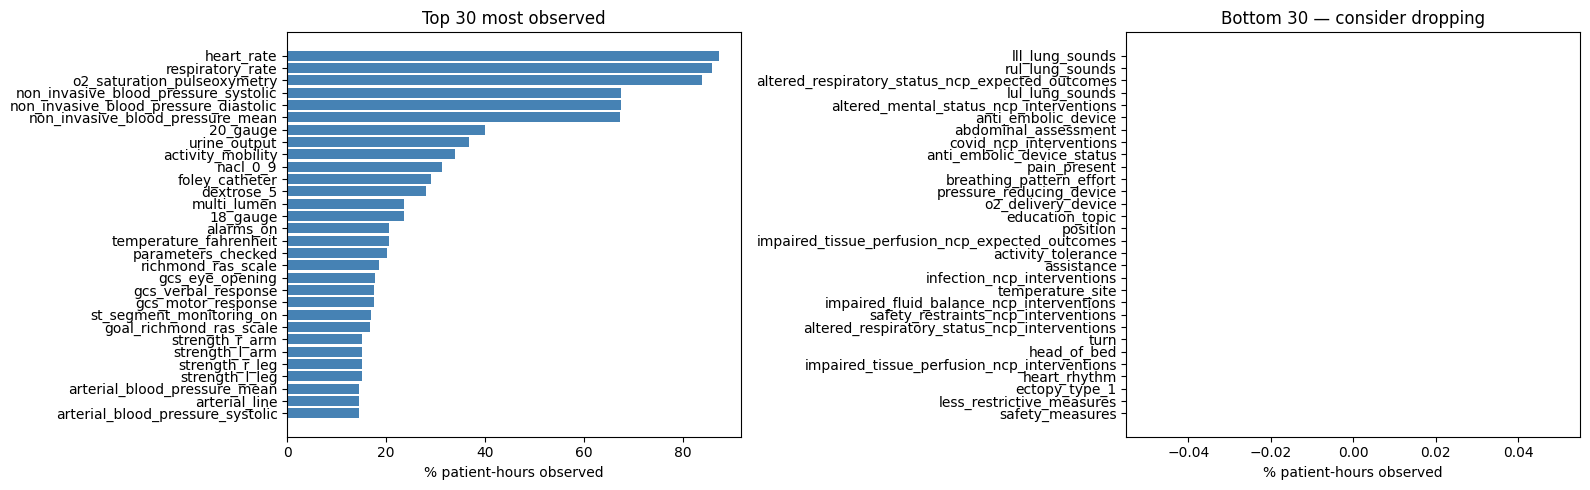


Clinical summary coverage:
  Has vitals data     : 14,946 / 14,968
  Has lab data        : 10,174 / 14,968
  Has active drugs    : 11,881 / 14,968
  Has active procedures: 12,041 / 14,968


In [ ]:
import numpy as np, matplotlib.pyplot as plt

X = np.array([c['time_series'] for c in cards])  # (N, 12, F)
y = np.array([c['label']       for c in cards])
print(f'X: {X.shape}  |  y: {y.shape}  |  {len(np.unique(y))} classes')

mask_idx   = [i for i, n in enumerate(FEATURE_COLS) if n.endswith('_mask')]
obs_rate   = X[:, :, mask_idx].mean(axis=(0, 1))
feat_names = [FEATURE_COLS[i].replace('_mask','') for i in mask_idx]

order  = np.argsort(obs_rate)[::-1]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top30 = order[:30]
axes[0].barh([feat_names[i] for i in top30][::-1],
             obs_rate[top30][::-1]*100, color='steelblue')
axes[0].set_xlabel('% patient-hours observed')
axes[0].set_title('Top 30 most observed')
bot30 = order[-30:]
axes[1].barh([feat_names[i] for i in bot30][::-1],
             obs_rate[bot30][::-1]*100, color='tomato')
axes[1].set_xlabel('% patient-hours observed')
axes[1].set_title('Bottom 30 — consider dropping')
plt.tight_layout(); plt.show()

# Summary coverage stats
n_vitals  = sum(1 for c in cards if c['clinical_summary']['vitals'])
n_labs    = sum(1 for c in cards if c['clinical_summary']['labs'])
n_drugs   = sum(1 for c in cards if c['clinical_summary']['interventions']['active_drugs'])
n_procs   = sum(1 for c in cards if c['clinical_summary']['interventions']['active_procedures'])
print(f'\nClinical summary coverage:')
print(f'  Has vitals data     : {n_vitals:,} / {len(cards):,}')
print(f'  Has lab data        : {n_labs:,} / {len(cards):,}')
print(f'  Has active drugs    : {n_drugs:,} / {len(cards):,}')
print(f'  Has active procedures: {n_procs:,} / {len(cards):,}')

**Example card**

In [ ]:
import numpy as np
import json

# ── Pull everything from cards[0] ────────────────────────────────────────────
card         = cards[0]
ts           = np.array(card['time_series'])          # (12, F)
feat_names   = card['feature_names']
n_timesteps, n_cols = ts.shape
n_features   = n_cols // 2                            # each feature = val + mask

# Separate val and mask matrices
val_mat  = ts[:, 0::2]   # (12, n_features)
mask_mat = ts[:, 1::2]   # (12, n_features)

# Base names (strip _val / _mask suffix)
base_names = [f.replace('_val','').replace('_mask','')
              for f in feat_names[0::2]]

# Features that have at least one observed hour
observed_idx   = [i for i in range(n_features) if mask_mat[:, i].sum() > 0]
observed_names = [base_names[i] for i in observed_idx]

print("=" * 60)
print(f"Patient  : {card['patient_id']}  |  stay: {card['stay_id']}")
print(f"ICD code : {card['icd_code']}  (label {card['label']})")
print(f"Tensor   : {ts.shape}  →  LSTM input (T=12, F={n_cols})")
print(f"Features : {n_features} total  |  {len(observed_idx)} observed  |  "
      f"{n_features - len(observed_idx)} all-zero")
print("=" * 60)

# ── Per-feature observation table ────────────────────────────────────────────
print(f"\n{'feature':<45} {'obs hrs':>7}  {'mean val':>10}  {'min':>8}  {'max':>8}")
print("-" * 85)
for i in observed_idx:
    hrs     = mask_mat[:, i]
    obs_h   = int(hrs.sum())
    obs_vals = val_mat[:, i][mask_mat[:, i] > 0]
    print(f"  {base_names[i]:<43} {obs_h:>5}/12  "
          f"{obs_vals.mean():>10.2f}  "
          f"{obs_vals.min():>8.2f}  "
          f"{obs_vals.max():>8.2f}")

# ── Hour-by-hour raw tensor (first 8 observed features) ──────────────────────
print(f"\n--- Hour-by-hour tensor (first 8 observed features) ---")
show_idx = observed_idx[:8]
header = f"{'hr':>4} | " + " | ".join(f"{observed_names[i][:12]:>14}" for i in range(len(show_idx)))
print(header)
print("-" * len(header))
for h in range(12):
    row = f" h{h:02d} | "
    for i in show_idx:
        v = val_mat[h, i]
        m = int(mask_mat[h, i])
        cell = f"{v:>12.2f}{'*' if m else ' '}"
        row += f" {cell} |"
    print(row)
print("  (* = observed this hour, blank = mask=0)")

# ── Sparsity summary ─────────────────────────────────────────────────────────
overall_obs_rate = mask_mat.mean()
print(f"\nOverall observation density : {overall_obs_rate*100:.1f}% of (hours × features)")
print(f"Urine output total          : "
      f"{val_mat[:, base_names.index('urine_output')].sum():.1f} mL"
      if 'urine_output' in base_names else "")

# ── PyHealth LSTM compatibility check ────────────────────────────────────────
print("\n--- PyHealth LSTM compatibility ---")
print(f"  time_series type    : {type(card['time_series']).__name__}")
print(f"  time_series[0] type : {type(card['time_series'][0]).__name__}")
print(f"  time_series[0][0]   : {type(card['time_series'][0][0]).__name__}  = "
      f"{card['time_series'][0][0]:.4f}")
print(f"  label type          : {type(card['label']).__name__}  = {card['label']}")
print(f"  All values finite   : {np.isfinite(ts).all()}")
print(f"  Masks all in {{0,1}}  : {np.isin(mask_mat, [0,1]).all()}")
print(f"  Val cols even index : {all(ts[:,i*2].mean() >= 0 for i in range(n_features))}")
print(f"  Mask cols odd index : {all(np.isin(ts[:,i*2+1],[0,1]).all() for i in range(n_features))}")
print("  LSTM-ready          : OK" if (
    np.isfinite(ts).all() and
    np.isin(mask_mat,[0,1]).all() and
    isinstance(card['label'], int)
) else "  WARNING: check above")

Patient  : 10001843  |  stay: 39698942
ICD code : A419  (label 0)
Tensor   : (12, 502)  →  LSTM input (T=12, F=502)
Features : 251 total  |  59 observed  |  192 all-zero

feature                                       obs hrs    mean val       min       max
-------------------------------------------------------------------------------------
  heart_rate                                      8/12      119.50     90.00    136.00
  respiratory_rate                                8/12       21.00     16.00     27.00
  o2_saturation_pulseoxymetry                     7/12       94.86     84.00     99.00
  non_invasive_blood_pressure_systolic            8/12       81.25     72.00     99.00
  non_invasive_blood_pressure_diastolic           8/12       52.38     27.00     66.00
  non_invasive_blood_pressure_mean                8/12       59.00     34.00     73.00
  orientation                                     2/12        1.00      1.00      1.00
  activity_mobility                             

In [ ]:
# Emit card data as JSON for the visualiser
import json

viz_data = {
    'patient_id': card['patient_id'],
    'icd_code':   card['icd_code'],
    'label':      card['label'],
    'shape':      list(ts.shape),
    'obs_names':  observed_names,
    'val_rows':   [[round(float(val_mat[h,i]),3) for i in observed_idx] for h in range(12)],
    'mask_rows':  [[int(mask_mat[h,i])           for i in observed_idx] for h in range(12)],
    'summary':    card['clinical_summary'],
}
print(json.dumps(viz_data, indent=2)[:3000], "\n... (truncated for display)")

{
  "patient_id": "10001843",
  "icd_code": "A419",
  "label": 0,
  "shape": [
    12,
    502
  ],
  "obs_names": [
    "heart_rate",
    "respiratory_rate",
    "o2_saturation_pulseoxymetry",
    "non_invasive_blood_pressure_systolic",
    "non_invasive_blood_pressure_diastolic",
    "non_invasive_blood_pressure_mean",
    "orientation",
    "activity_mobility",
    "temperature_fahrenheit",
    "richmond_ras_scale",
    "gcs_eye_opening",
    "gcs_verbal_response",
    "gcs_motor_response",
    "goal_richmond_ras_scale",
    "inspired_o2_fraction",
    "strength_r_arm",
    "strength_l_arm",
    "strength_r_leg",
    "strength_l_leg",
    "glucose_finger_stick",
    "h",
    "l",
    "i",
    "potassium",
    "sodium",
    "chloride",
    "creatinine",
    "urea_nitrogen",
    "bicarbonate",
    "anion_gap",
    "glucose",
    "magnesium",
    "hematocrit",
    "hemoglobin",
    "platelet_count",
    "phosphate",
    "white_blood_cells",
    "mch",
    "mcv",
    "red_blood_cells",


## 14 · Save

In [ ]:
import json

output = {
    'label_map':     label_map,
    'feature_names': FEATURE_COLS,
    'n_features':    len(FEATURE_COLS),
    'n_timesteps':   12,
    # Full vocab for interpretability / SHAP post-hoc
    'item_vocab': {
        'chartevents':      {str(k): v for k, v in CHART_NAME_MAP.items()},
        'labevents':        {str(k): v for k, v in LAB_NAME_MAP.items()},
        'inputevents':      {str(k): v for k, v in INPUT_NAME_MAP.items()},
        'procedureevents':  {str(k): v for k, v in PROC_NAME_MAP.items()},
    },
    'patients': cards,
}

with open(OUT_PATH, 'w') as f:
    json.dump(output, f)

size_mb = os.path.getsize(OUT_PATH) / 1e6
X_final = np.array([c['time_series'] for c in cards])
print(f'Saved → {OUT_PATH}  ({size_mb:.1f} MB)')
print(f'LSTM input shape : {X_final.shape}  (N × T=12 × F={X_final.shape[2]})')
print(f'Each card also has clinical_summary for debate agents.')

Saved → /content/drive/MyDrive/patient_cards_v2.json  (744.8 MB)
LSTM input shape : (14968, 12, 502)  (N × T=12 × F=502)
Each card also has clinical_summary for debate agents.
